In [11]:
from datasets import load_dataset
dataset = load_dataset("uoft-cs/cifar10")
print(dataset)
print(dataset['train'][0]['img'].size)

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})
(32, 32)


In [12]:
import numpy as np
from datasets import load_dataset

# Normalize pixel values and convert PIL images to numpy arrays
def preprocess(batch):
    batch['pixel_values'] = [np.array(img, dtype=np.float32) / 255.0 for img in batch['img']]
    return batch

dataset = dataset.map(preprocess, batched=True, remove_columns=['img'])
print("Preprocessing done.")
print(f"Sample shape: {np.array(dataset['train'][0]['pixel_values']).shape}")

Preprocessing done.
Sample shape: (32, 32, 3)


In [13]:
# Split training into 10% labeled and 90% unlabeled
split = dataset['train'].train_test_split(test_size=0.90, seed=42)
labeled_ds   = split['train']   # 5,000 images - used for supervised training
unlabeled_ds = split['test']    # 45,000 images - labels hidden during training

test_ds = dataset['test']       # 10,000 images - held out for final evaluation

print(f"Labeled:   {len(labeled_ds)}")
print(f"Unlabeled: {len(unlabeled_ds)}")
print(f"Test:      {len(test_ds)}")

Labeled:   5000
Unlabeled: 45000
Test:      10000


In [14]:
def to_numpy(ds):
    X = np.array(ds['pixel_values'], dtype=np.float32)
    y = np.array(ds['label'], dtype=np.int32)
    return X, y

X_labeled,   y_labeled   = to_numpy(labeled_ds)
X_unlabeled, y_unlabeled = to_numpy(unlabeled_ds)  # y_unlabeled will be hidden during training
X_test,      y_test      = to_numpy(test_ds)

print(f"X_labeled:   {X_labeled.shape}, y_labeled:   {y_labeled.shape}")
print(f"X_unlabeled: {X_unlabeled.shape}, y_unlabeled: {y_unlabeled.shape}")
print(f"X_test:      {X_test.shape}, y_test:      {y_test.shape}")

X_labeled:   (5000, 32, 32, 3), y_labeled:   (5000,)
X_unlabeled: (45000, 32, 32, 3), y_unlabeled: (45000,)
X_test:      (10000, 32, 32, 3), y_test:      (10000,)


In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']

# Data augmentation
augmentation = keras.Sequential([layers.RandomFlip("horizontal"),layers.RandomRotation(0.1),layers.RandomZoom(0.1),], name="augmentation")

print("Augmentation pipeline ready.")
print(tf.__version__)

Augmentation pipeline ready.
2.19.0


In [16]:
def build_model():
    model = keras.Sequential([
        keras.Input(shape=(32, 32, 3)),

        # Augmentation (only active during training)
        augmentation,

        # Block 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Dense head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,57

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [17]:
# Stage 1: Supervised training on labeled set only (5,000 images)
print("Stage 1: Training on labeled set")

history_stage1 = model.fit(
    X_labeled, y_labeled,
    validation_data=(X_test, y_test),
    batch_size=64,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
    ]
)

Stage 1: Training on labeled set
Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 67s 776ms/step - accuracy: 0.2116 - loss: 2.8911 - val_accuracy: 0.1041 - val_loss: 3.1450 - learning_rate: 0.0010
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 83s 782ms/step - accuracy: 0.3201 - loss: 2.1300 - val_accuracy: 0.0990 - val_loss: 3.4206 - learning_rate: 0.0010
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 60s 764ms/step - accuracy: 0.3696 - loss: 1.9097 - val_accuracy: 0.1384 - val_loss: 4.0013 - learning_rate: 0.0010
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.3744 - loss: 1.7677
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
79/79 ━━━━━━━━━━━━━━━━━━━━ 57s 719ms/step - accuracy: 0.3745 - loss: 1.7673 - val_accuracy: 0.1579 - val_loss: 3.7663 - learning_rate: 0.0010
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 55s 698ms/step - accuracy: 0.4155 - loss: 1.6761 - val_accuracy: 0.2353 - val_loss: 2.5360 - learning_rate: 5.0000e-04
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 61s 771ms

In [18]:
# Evaluate Stage 1 baseline
test_loss_s1, test_acc_s1 = model.evaluate(X_test, y_test, verbose=0)
print(f"Stage 1 - Test Accuracy: {test_acc_s1:.4f}")
print(f"Stage 1 - Test Loss:     {test_loss_s1:.4f}")

Stage 1 - Test Accuracy: 0.4781
Stage 1 - Test Loss:     1.4570


In [19]:
# Generate pseudo-labels for the unlabeled set
# Only keep predictions where the model is confident (probability >= 0.90)
CONFIDENCE_THRESHOLD = 0.90

predictions = model.predict(X_unlabeled, batch_size=64, verbose=1)
max_probs = np.max(predictions, axis=1)       # highest probability for each image
pseudo_labels = np.argmax(predictions, axis=1) # predicted class for each image

# Filter to only confident predictions
confident_mask = max_probs >= CONFIDENCE_THRESHOLD
X_pseudo = X_unlabeled[confident_mask]
y_pseudo  = pseudo_labels[confident_mask]

print(f"Total unlabeled:     {len(X_unlabeled)}")
print(f"Confident pseudo-labels: {len(X_pseudo)} ({100*len(X_pseudo)/len(X_unlabeled):.1f}%)")
print(f"Discarded (low confidence): {len(X_unlabeled) - len(X_pseudo)}")

704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 97ms/step
Total unlabeled:     45000
Confident pseudo-labels: 3535 (7.9%)
Discarded (low confidence): 41465


In [20]:
CONFIDENCE_THRESHOLD = 0.70

confident_mask = max_probs >= CONFIDENCE_THRESHOLD
X_pseudo = X_unlabeled[confident_mask]
y_pseudo  = pseudo_labels[confident_mask]

print(f"Total unlabeled:            {len(X_unlabeled)}")
print(f"Confident pseudo-labels:    {len(X_pseudo)} ({100*len(X_pseudo)/len(X_unlabeled):.1f}%)")
print(f"Discarded (low confidence): {len(X_unlabeled) - len(X_pseudo)}")

Total unlabeled:            45000
Confident pseudo-labels:    11468 (25.5%)
Discarded (low confidence): 33532


In [21]:
# Combine labeled and pseudo-labeled data
X_combined = np.concatenate([X_labeled, X_pseudo], axis=0)
y_combined = np.concatenate([y_labeled, y_pseudo], axis=0)

print(f"Labeled:       {len(X_labeled)}")
print(f"Pseudo-labeled:{len(X_pseudo)}")
print(f"Combined total:{len(X_combined)}")

Labeled:       5000
Pseudo-labeled:11468
Combined total:16468


In [23]:
# Stage 2: Retrain on labeled + pseudo-labeled data (weighted + lower LR)
X_combined_weighted = np.concatenate([X_labeled, X_labeled, X_pseudo], axis=0)
y_combined_weighted = np.concatenate([y_labeled, y_labeled, y_pseudo], axis=0)
print(f"Combined (weighted): {len(X_combined_weighted)}")

# Build fresh model with lower learning rate baked in
model_stage2 = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    augmentation,
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_stage2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_stage2 = model_stage2.fit(
    X_combined_weighted, y_combined_weighted,
    validation_data=(X_test, y_test),
    batch_size=64,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
    ]
)

Combined (weighted): 21468
Epoch 1/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 173s 495ms/step - accuracy: 0.4583 - loss: 1.9937 - val_accuracy: 0.1539 - val_loss: 4.4643 - learning_rate: 3.0000e-04
Epoch 2/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 168s 501ms/step - accuracy: 0.6389 - loss: 1.2202 - val_accuracy: 0.3935 - val_loss: 2.2270 - learning_rate: 3.0000e-04
Epoch 3/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 164s 488ms/step - accuracy: 0.6722 - loss: 1.0689 - val_accuracy: 0.4146 - val_loss: 2.0604 - learning_rate: 3.0000e-04
Epoch 4/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 175s 522ms/step - accuracy: 0.6982 - loss: 0.9801 - val_accuracy: 0.4230 - val_loss: 1.8789 - learning_rate: 3.0000e-04
Epoch 5/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 181s 538ms/step - accuracy: 0.7163 - loss: 0.8954 - val_accuracy: 0.4175 - val_loss: 2.1553 - learning_rate: 3.0000e-04
Epoch 6/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 171s 509ms/step - accuracy: 0.7210 - loss: 0.8780 - val_accuracy: 0.4124 - val_loss: 2.1919 - learning_rate: 3.0000e-04
Epoch 7/30
33

In [24]:
# Fine-tune the Stage 1 model directly on high confidence pseudo-labels only
# Use a very low learning rate to preserve what it already learned

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Only use high confidence pseudo-labels (0.80+)
confident_mask_80 = max_probs >= 0.80
X_pseudo_80 = X_unlabeled[confident_mask_80]
y_pseudo_80 = pseudo_labels[confident_mask_80]

# Combine with labeled data
X_finetune = np.concatenate([X_labeled, X_labeled, X_pseudo_80], axis=0)
y_finetune = np.concatenate([y_labeled, y_labeled, y_pseudo_80], axis=0)

print(f"High confidence pseudo-labels (0.80+): {len(X_pseudo_80)}")
print(f"Finetune total: {len(X_finetune)}")

history_stage2 = model.fit(
    X_finetune, y_finetune,
    validation_data=(X_test, y_test),
    batch_size=64,
    epochs=20,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
    ]
)

High confidence pseudo-labels (0.80+): 7235
Finetune total: 17235
Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 153s 540ms/step - accuracy: 0.6353 - loss: 1.0790 - val_accuracy: 0.4154 - val_loss: 1.8310 - learning_rate: 5.0000e-05
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 142s 525ms/step - accuracy: 0.6874 - loss: 0.9516 - val_accuracy: 0.4345 - val_loss: 1.7929 - learning_rate: 5.0000e-05
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 142s 523ms/step - accuracy: 0.6977 - loss: 0.9224 - val_accuracy: 0.4313 - val_loss: 1.8490 - learning_rate: 5.0000e-05
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 134s 498ms/step - accuracy: 0.6958 - loss: 0.9214 - val_accuracy: 0.4382 - val_loss: 1.8613 - learning_rate: 5.0000e-05
Epoch 5/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 140s 492ms/step - accuracy: 0.7025 - loss: 0.9025 - val_accuracy: 0.4597 - val_loss: 1.7503 - learning_rate: 5.0000e-05
Epoch 6/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 140s 518ms/step - accuracy: 0.7090 - loss: 0.8828 - val_accuracy: 0.4402 - val_loss: 1.8532 - 

In [25]:
test_loss_s2, test_acc_s2 = model.evaluate(X_test, y_test, verbose=0)
print(f"Stage 1 Test Accuracy: {test_acc_s1:.4f}")
print(f"Stage 2 Test Accuracy: {test_acc_s2:.4f}")
print(f"Difference: {(test_acc_s2 - test_acc_s1)*100:+.2f}%")

Stage 1 Test Accuracy: 0.4781
Stage 2 Test Accuracy: 0.4662
Difference: -1.19%


157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 161ms/step
Classification Report:
              precision    recall  f1-score   support

    airplane       0.74      0.38      0.50      1000
  automobile       0.70      0.60      0.65      1000
        bird       0.72      0.09      0.15      1000
         cat       0.37      0.12      0.19      1000
        deer       0.42      0.20      0.28      1000
         dog       0.62      0.27      0.37      1000
        frog       0.26      0.96      0.41      1000
       horse       0.59      0.62      0.60      1000
        ship       0.55      0.78      0.65      1000
       truck       0.57      0.63      0.60      1000

    accuracy                           0.47     10000
   macro avg       0.55      0.47      0.44     10000
weighted avg       0.55      0.47      0.44     10000



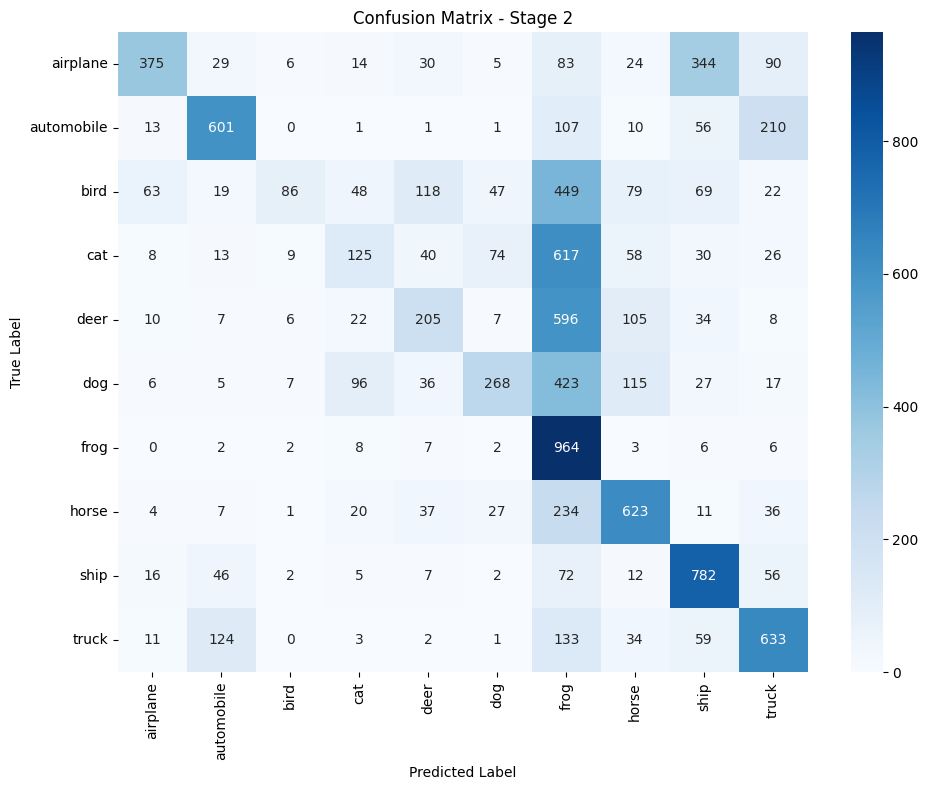

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- Classification Report ---
y_pred = np.argmax(model.predict(X_test, batch_size=64), axis=1)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Stage 2')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

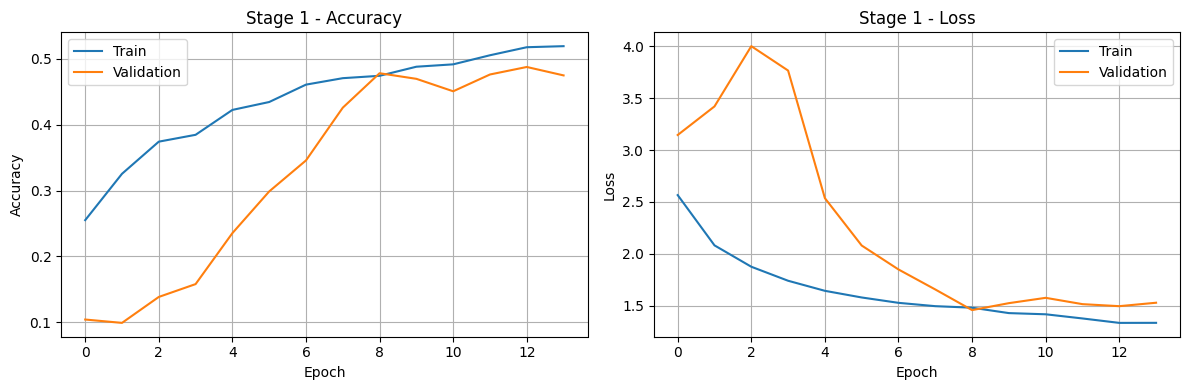

In [27]:
# Training Curves Stage 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_stage1.history['accuracy'], label='Train')
ax1.plot(history_stage1.history['val_accuracy'], label='Validation')
ax1.set_title('Stage 1 - Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(history_stage1.history['loss'], label='Train')
ax2.plot(history_stage1.history['val_loss'], label='Validation')
ax2.set_title('Stage 1 - Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

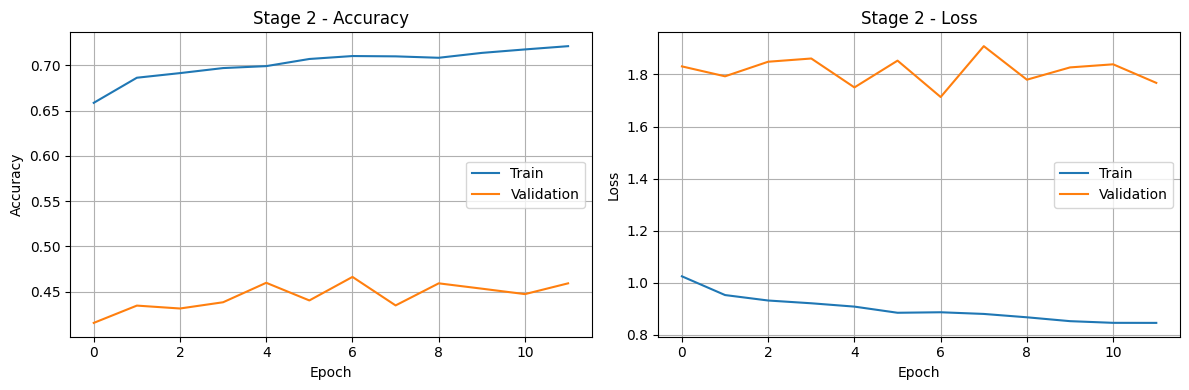

In [28]:
# Training Curves Stage 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_stage2.history['accuracy'], label='Train')
ax1.plot(history_stage2.history['val_accuracy'], label='Validation')
ax1.set_title('Stage 2 - Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(history_stage2.history['loss'], label='Train')
ax2.plot(history_stage2.history['val_loss'], label='Validation')
ax2.set_title('Stage 2 - Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

In [29]:
#Stage 1 accuracy: 47.81% (trained on 5,000 labeled images)
#Stage 2 accuracy: 46.62% (after pseudo-labeling — slightly worse)
#Frog is dominating predictions (recall 0.96) — the model is over-predicting frog for uncertain images
#Bird and cat are nearly unrecognized (F1 of 0.15 and 0.19)